2.1 理论计算题
已知：  
a = [2, -1, 3]ᵀ  
b = [1, 4, -2]ᵀ  

矩阵  
A = [ [1, 0, 2],  
      [-1, 3, 1] ]   (2行3列)  

B = [ [2, 1],  
      [0, -1],  
      [3, 2] ]       (3行2列)

---

 1. 向量点积 a·b

2×1 = 2  
(-1)×4 = -4  
3×(-2) = -6  
相加：2 + (-4) + (-6) = -8  

答案：-8

---

2. 矩阵乘法 A×B

A 是 2×3，B 是 3×2，结果矩阵是 2×2。

计算：  
第1行第1列：1×2 + 0×0 + 2×3 = 2 + 0 + 6 = 8  
第1行第2列：1×1 + 0×(-1) + 2×2 = 1 + 0 + 4 = 5  
第2行第1列：(-1)×2 + 3×0 + 1×3 = -2 + 0 + 3 = 1  
第2行第2列：(-1)×1 + 3×(-1) + 1×2 = -1 -3 + 2 = -2  

结果矩阵：  
[ [8, 5],  
  [1, -2] ]

形状：2×2

---

 3. 向量 a 的 Frobenius 范数

公式：√(2² + (-1)² + 3²) = √(4 + 1 + 9) = √14  

答案：√14

In [1]:
import numpy as np

# 2.2 编程题
np.random.seed(42)
X = np.random.randn(3, 4)          # 形状 3x4，标准正态分布
Y = np.ones((4, 2))                # 形状 4x2，全1矩阵
Z = X @ Y                          # 矩阵乘法

print("Z 的形状:", Z.shape)
print("Z 的第一行第二列元素:", Z[0, 1])
print("Z 的第二行所有元素:", Z[1, :])
print("Z 的 Frobenius 范数:", np.linalg.norm(Z, 'fro'))



Z 的形状: (3, 2)
Z 的第一行第二列元素: 2.5291682463487657
Z 的第二行所有元素: [1.87835721 1.87835721]
Z 的 Frobenius 范数: 4.616873319476864


## 3.1 理论计算题

已知：  
患病率 P(病) = 0.1% = 0.001  
灵敏度 P(阳|病) = 99% = 0.99  
假阳性率 P(阳|无病) = 2% = 0.02  

求：检测为阳性时真正患病的概率 P(病|阳)

---

贝叶斯公式：  
P(病|阳) = [P(阳|病)×P(病)] / [P(阳|病)×P(病) + P(阳|无病)×P(无病)]

代入数字：  
分子 = 0.99 × 0.001 = 0.00099  
分母 = 0.00099 + 0.02 × (1 - 0.001) = 0.00099 + 0.01998 = 0.02097  

结果 = 0.00099 / 0.02097 ≈ 0.0472  
即约 4.72%

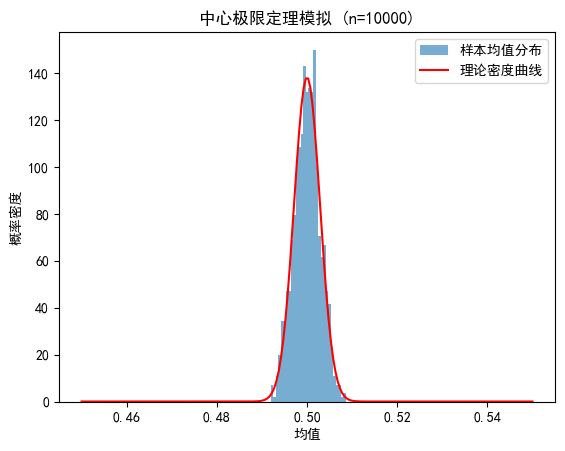

实际方差: 0.0000083142
理论方差: 0.0000083333


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

n = 10000      # 每个样本的变量个数
m = 1000       # 重复次数
means = []

for _ in range(m):
    sample = np.random.uniform(0, 1, n)
    means.append(np.mean(sample))

means = np.array(means)
actual_var = np.var(means, ddof=0)

plt.hist(means, bins=30, density=True, alpha=0.6, label='样本均值分布')

mu_theory = 0.5
sigma_theory = np.sqrt(1/(12*n))
x = np.linspace(0.45, 0.55, 200)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', label='理论密度曲线')
plt.xlabel('均值')
plt.ylabel('概率密度')
plt.legend()
plt.title('中心极限定理模拟 (n=10000)')
plt.show()

print(f"实际方差: {actual_var:.10f}")
print(f"理论方差: {sigma_theory**2:.10f}")

## 4.1 理论计算题

函数：z = (w₁·x₁ + w₂·x₂ - y)²  
常数：x₁=2, x₂=1, y=3  
变量：w₁, w₂

---

1. 偏导表达式  
先算中间量 u = w₁·2 + w₂·1 - 3  
导数：  
∂z/∂w₁ = 2u · x₁ = 2u × 2 = 4u  
∂z/∂w₂ = 2u · x₂ = 2u × 1 = 2u  
其中 u = 2w₁ + w₂ - 3

2. 代入 w₁=0.5, w₂=1  
u = 2×0.5 + 1 - 3 = 1 + 1 - 3 = -1  
∂z/∂w₁ = 4 × (-1) = -4  
∂z/∂w₂ = 2 × (-1) = -2

In [1]:
import torch

x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2
print(f"前向计算结果: L = {L}")

# 手动梯度
b_val = a + w2
dL_db = 2 * b_val
dL_dw1 = dL_db * 1 * x
dL_dw2 = dL_db * 1
print(f"手动梯度: dL/dw1 = {dL_dw1}, dL/dw2 = {dL_dw2}")

# 自动微分
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()
print(f"自动微分梯度: dL/dw1 = {w1_t.grad.item()}, dL/dw2 = {w2_t.grad.item()}")
print("两者一致，验证通过。")

前向计算结果: L = 12.25
手动梯度: dL/dw1 = 14.0, dL/dw2 = 7.0
自动微分梯度: dL/dw1 = 14.0, dL/dw2 = 7.0
两者一致，验证通过。


## 5.1 理论计算题

模型：y = wx + b  
损失函数：L = (1/n) Σ (y_i - (w x_i + b))²

---

对 w 的偏导：  
∂L/∂w = (1/n) Σ 2(y_i - w x_i - b)·(-x_i)  
= - (2/n) Σ x_i (y_i - w x_i - b)

对 b 的偏导：  
∂L/∂b = (1/n) Σ 2(y_i - w x_i - b)·(-1)  
= - (2/n) Σ (y_i - w x_i - b)



In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

digits = load_digits()
X = digits.data
y = digits.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

num_features = X_train.shape[1]
num_classes = 10
W = np.random.randn(num_features, num_classes) * 0.01
b = np.zeros((1, num_classes))

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / m

lr = 0.1
batch_size = 32
epochs = 50
num_train = X_train.shape[0]

for epoch in range(epochs):
    indices = np.random.permutation(num_train)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    for i in range(0, num_train, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        grad_logits = (y_pred - y_batch) / batch_size
        grad_W = X_batch.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)
        W -= lr * grad_W
        b -= lr * grad_b

logits_test = X_test @ W + b
y_test_pred = softmax(logits_test)
y_test_labels = np.argmax(y_test_pred, axis=1)
accuracy = np.mean(y_test_labels == y_test.flatten())
print(f"Softmax 回归测试准确率: {accuracy*100:.2f}%")

Softmax 回归测试准确率: 96.39%


## 6.1 理论计算题

样本：x₁, x₂, …, xₙ 独立同分布 ~ N(μ, σ²)

---

1. 似然函数  
L(μ,σ²) = (2πσ²)^{-n/2} exp[ -1/(2σ²) Σ (x_i - μ)² ]

2. μ 的最大似然估计  
对 lnL 求导，令为 0：  
Σ (x_i - μ) = 0  →  μ̂ = (1/n) Σ x_i  （样本均值）

3. σ² 的最大似然估计  
将 μ̂ 代入，对 σ² 求导：  
得 σ̂² = (1/n) Σ (x_i - μ̂)²  （样本方差，分母为 n）

逻辑回归测试准确率: 86.00%


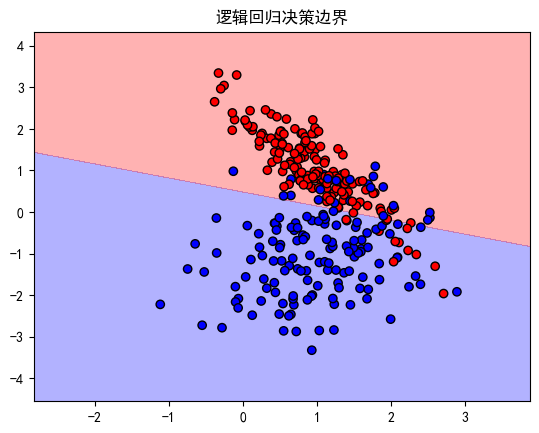

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, flip_y=0, random_state=42)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1-y_true) * np.log(1-y_pred + 1e-8))

w = np.random.randn(2, 1)
b = 0.0
lr = 0.1
iters = 1000

for i in range(iters):
    logits = X_train @ w + b
    y_pred = sigmoid(logits)
    dw = (X_train.T @ (y_pred - y_train)) / len(y_train)
    db = np.mean(y_pred - y_train)
    w -= lr * dw
    b -= lr * db

y_test_pred_prob = sigmoid(X_test @ w + b)
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)
accuracy = np.mean(y_test_pred == y_test)
print(f"逻辑回归测试准确率: {accuracy*100:.2f}%")

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w + b)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
plt.scatter(X_train[:,0], X_train[:,1], c=y_train.ravel(), edgecolors='k', cmap='bwr')
plt.title("逻辑回归决策边界")
plt.show()